# HBV Constant Su_max Calibration

This notebook runs the constant-Su_max HBV model from hbv_bmi_constant.py with a multi-objective Monte Carlo calibration and calibration/validation split.

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_constant import HBV_Bmi

In [3]:
base = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
temp_path = base / 'ERA5_Temp_1980_2026.csv'
precip_path = base / 'Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv'
evap_path = base / 'Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv'
grdc_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')
shape_area = 28191724718  # m2

In [3]:
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    den = np.sum((obs - np.mean(obs)) ** 2)
    if den <= 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / den

def log_nse(obs, sim, eps=1e-6):
    obs = np.maximum(np.asarray(obs, dtype=float), eps)
    sim = np.maximum(np.asarray(sim, dtype=float), eps)
    return nse(np.log(obs), np.log(sim))

def rel_bias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    s_obs = np.sum(obs)
    if s_obs == 0:
        return np.nan
    return (np.sum(sim) - s_obs) / s_obs

def combined_score(obs, sim, w_nse=0.45, w_lognse=0.35, w_bias=0.20):
    a = nse(obs, sim)
    b = log_nse(obs, sim)
    c = rel_bias(obs, sim)
    if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(c)):
        return np.nan
    return w_nse * a + w_lognse * b - w_bias * abs(c)

In [5]:
# Import hourly data, resample to daily, and clip to Exercise 3 period (2010-2012)
from pathlib import Path
import pandas as pd

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))

df_p = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
df_e = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

# Parse hourly timestamp format like 20110101T00
for frame in (df_p, df_e):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

p_col = [c for c in df_p.columns if c not in ['system:index', 'time']][0]
e_col = [c for c in df_e.columns if c not in ['system:index', 'time']][0]

# Sum hourly depths to daily totals (ERA5 hourly totals are accumulated depth per hour)
df_p_daily = (
    df_p.set_index('time')[[p_col]]
    .resample('D').sum()
    .rename(columns={p_col: 'precip_m_day'})
)

df_e_daily = (
    df_e.set_index('time')[[e_col]]
    .resample('D').sum()
    .rename(columns={e_col: 'evap_m_day'})
)

# Clip to the Exercise 3 period
start_ex3 = pd.Timestamp('2010-01-01')
end_ex3 = pd.Timestamp('2012-12-31')

df_p_daily = df_p_daily.loc[start_ex3:end_ex3]
df_e_daily = df_e_daily.loc[start_ex3:end_ex3]

# Overwrite df_p and df_e with daily clipped data for downstream use
df_p = df_p_daily.copy()
df_e = df_e_daily.copy()

print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731
Daily evaporation range:   2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731


,precip_m_day,evap_m_day
time,,
2011-01-01,0.000623,-0.000018
2011-01-02,0.000219,-0.000168
2011-01-03,0.000124,-0.000085


## Daily Monte Carlo

In [21]:
# Build daily forcing and daily observed discharge for 2011-2014 (2011 warmup)
# Self-contained so it can run even if earlier cells were not executed.
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr

start_mc = pd.Timestamp('2011-01-01')
end_mc = pd.Timestamp('2014-12-31')

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Ensure daily forcing exists and covers the requested window; otherwise rebuild from hourly files.
need_rebuild = True
if ('df_p' in globals()) and ('df_e' in globals()):
    try:
        need_rebuild = (df_p.index.min() > start_mc) or (df_p.index.max() < end_mc) or (df_e.index.min() > start_mc) or (df_e.index.max() < end_mc)
    except Exception:
        need_rebuild = True

if need_rebuild:
    df_p_h = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
    df_e_h = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

    for frame in (df_p_h, df_e_h):
        frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

    p_col = [c for c in df_p_h.columns if c not in ['system:index', 'time']][0]
    e_col = [c for c in df_e_h.columns if c not in ['system:index', 'time']][0]

    df_p = df_p_h.set_index('time')[[p_col]].resample('D').sum().rename(columns={p_col: 'precip_m_day'})
    df_e = df_e_h.set_index('time')[[e_col]].resample('D').sum().rename(columns={e_col: 'evap_m_day'})

# Convert forcing to mm/day and ensure positive PET sign
daily_forcing = pd.concat([df_p, df_e], axis=1).loc[start_mc:end_mc].copy()
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0

# Daily observed Q in mm/day
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Calibration score period excludes warmup year
cal_mask = (daily_forcing.index >= pd.Timestamp('2012-01-01')) & (daily_forcing.index <= pd.Timestamp('2014-12-31'))

# Write daily forcing to temporary NetCDF files
run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)
run_tag_daily = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')

pr_daily_ds = xr.Dataset({'pr': ('time', daily_forcing['pr_mm_day'].to_numpy(dtype=float))}, coords={'time': daily_forcing.index})
pet_daily_ds = xr.Dataset({'evspsblpot': ('time', daily_forcing['pet_mm_day'].to_numpy(dtype=float))}, coords={'time': daily_forcing.index})

pr_daily_path = run_dir / f'tmp_pr_daily_{run_tag_daily}.nc'
pet_daily_path = run_dir / f'tmp_pet_daily_{run_tag_daily}.nc'
cfg_daily_path = run_dir / f'tmp_hbv_daily_config_{run_tag_daily}.json'

pr_daily_ds.to_netcdf(pr_daily_path, mode='w')
pet_daily_ds.to_netcdf(pet_daily_path, mode='w')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Calibration score period (after warmup): 2012-01-01 to 2014-12-31')
print('Daily files written:')
print(pr_daily_path)
print(pet_daily_path)

MC forcing period: 2011-01-01 00:00:00 to 2014-12-31 00:00:00 | n = 1461
Calibration score period (after warmup): 2012-01-01 to 2014-12-31
Daily files written:
/Users/doriswong/tmp_hbv_constant/tmp_pr_daily_20260404_132250_630864.nc
/Users/doriswong/tmp_hbv_constant/tmp_pet_daily_20260404_132250_630864.nc


In [22]:
# MC simulation for 2011-2014 with 2011 warmup (score on 2012-2014)
# Define metrics locally if previous function cell has not been run.
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

ParMinn_mc = np.array([0.0, 0.2, 40.0, 0.5, 0.001, 0.0, 0.01, 0.0001])
ParMaxn_mc = np.array([8.0, 1.0, 800.0, 4.0, 0.3, 10.0, 0.1, 0.01])

N_mc = 1000
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg = {
        'precipitation_file': str(pr_daily_path),
        'potential_evaporation_file': str(pet_daily_path),
        'parameters': ','.join([f'{v:.10f}' for v in p]),
        'initial_storage': '0.0,100.0,0.0,5.0',
    }
    with open(cfg_daily_path, 'w') as f:
        json.dump(cfg, f)

    m = HBV_Bmi()
    m.initialize(str(cfg_daily_path))

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
summary_daily

Valid runs: 1000 / 1000


,metric,value
0,NSE_cal_2012_2014,0.766061
1,logNSE_cal_2012_2014,0.754783
2,rel_bias_cal_2012_2014,0.049105


In [25]:
print(best_daily)

{'params': array([2.66513528e+00, 3.19149142e-01, 2.63783935e+02, 1.26387331e+00,
       7.57982473e-02, 3.47496049e+00, 9.91091167e-02, 1.10481901e-03]), 'sim_mm_day': array([1.23463003e-03, 4.32687834e-03, 5.58134923e-03, ...,
       1.87508841e+00, 1.75750036e+00, 1.62888979e+00], shape=(1461,)), 'nse_cal': np.float64(0.7660613013378837), 'lognse_cal': np.float64(0.7547827464589246), 'rb_cal': np.float64(0.04910508844010792)}


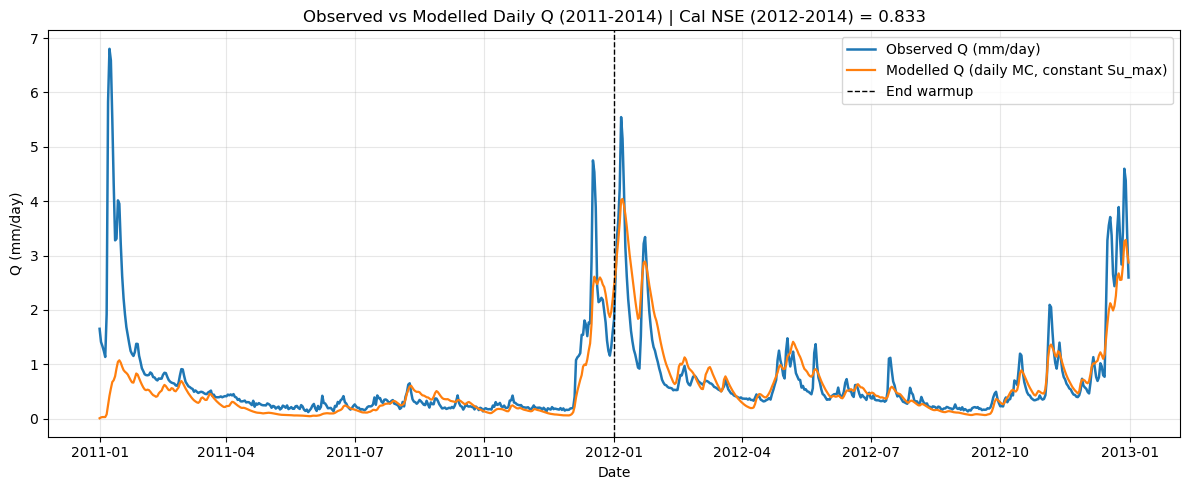

,metric,value
0,NSE_cal_2012_2014,0.833137
1,logNSE_cal_2012_2014,0.778813
2,rel_bias_cal_2012_2014,0.035360


In [20]:
# Plot best daily MC hydrograph for 2011-2014 (2011 warmup + 2012-2014 calibration score)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', lw=1.8)
ax.plot(daily_forcing.index, sim_daily_best, label='Modelled Q (daily MC, constant Su_max)', lw=1.6)
ax.axvline(pd.Timestamp('2012-01-01'), color='k', ls='--', lw=1, label='End warmup')
ax.set_title(f'Observed vs Modelled Daily Q (2011-2014) | Cal NSE (2012-2014) = {best_daily["nse_cal"]:.3f}')
ax.set_xlabel('Date')
ax.set_ylabel('Q (mm/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

summary_daily

## Decadal Su_max Estimation (No Validation)

This section calibrates the constant-Su_max HBV model separately for each decade using only a calibration window (no validation split).

Spin-up handling used here:
- Each decade is scored on January 1 of year Y to December 31 of year Y+9.
- The model is initialized one year earlier when data are available, and that spin-up year is not included in scoring.
- For the first available decade, if a full 1-year pre-decade period is not available, spin-up is shorter. Interpret that decade with extra caution.

In [7]:
# Calibrate one constant Su_max per decade (no validation split)
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import json
from tqdm.notebook import tqdm

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Load stitched daily forcing (1980-2025)
precip_daily = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')

for frame in (precip_daily, evap_daily):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')
    frame.set_index('time', inplace=True)

precip_daily['total_precipitation_daily'] = pd.to_numeric(
    precip_daily['total_precipitation_daily'], errors='coerce'
).replace(-9999, np.nan)
evap_daily['total_evaporation_daily'] = pd.to_numeric(
    evap_daily['total_evaporation_daily'], errors='coerce'
).replace(-9999, np.nan)

forcing_all = pd.DataFrame(index=precip_daily.index.union(evap_daily.index).sort_values())
forcing_all['pr_mm_day'] = precip_daily['total_precipitation_daily'].reindex(forcing_all.index) * 1000.0
forcing_all['pet_mm_day'] = (-evap_daily['total_evaporation_daily'].reindex(forcing_all.index)).clip(lower=0) * 1000.0

forcing_all['pr_mm_day'] = forcing_all['pr_mm_day'].interpolate(limit_direction='both')
forcing_all['pet_mm_day'] = forcing_all['pet_mm_day'].interpolate(limit_direction='both')

# Load observed discharge and convert to mm/day
grdc_all = pd.read_csv(
    grdc_path_local,
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_all.columns = ['q_m3s']
grdc_all['q_m3s'] = grdc_all['q_m3s'].replace(-999, np.nan) 

q_obs_mm_day = (
    grdc_all['q_m3s']
    .reindex(forcing_all.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

all_data = forcing_all.copy()
all_data['q_obs_mm_day'] = q_obs_mm_day
all_data = all_data.dropna(subset=['pr_mm_day', 'pet_mm_day', 'q_obs_mm_day']).copy()

if all_data.empty:
    raise RuntimeError('No overlapping forcing and discharge data available for decadal calibration.')

ParMinn_mc = np.array([0.0, 0.2, 40.0, 0.5, 0.001, 0.0, 0.01, 0.0001])
ParMaxn_mc = np.array([9.0, 1.0, 800.0, 4.0, 0.3, 10.0, 0.5, 0.02])
param_names = ['Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks']

N_mc_decade = 100

run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)

first_year = int(all_data.index.min().year)
last_year = int(all_data.index.max().year)
decade_starts = list(range((first_year // 10) * 10, last_year + 1, 10))

decade_results = []

for decade_start in tqdm(decade_starts, desc='Decades', unit='decade'):
    decade_end = decade_start + 9
    score_start = max(pd.Timestamp(f'{decade_start}-01-01'), all_data.index.min())
    score_end = min(pd.Timestamp(f'{decade_end}-12-31'), all_data.index.max())

    if score_end <= score_start:
        continue

    sim_start = max(all_data.index.min(), score_start - pd.Timedelta(days=365))
    run_df = all_data.loc[sim_start:score_end].copy()
    if len(run_df) < 365:
        continue

    score_mask = (run_df.index >= score_start) & (run_df.index <= score_end)
    n_score_days = int(score_mask.sum())
    if n_score_days < 365 * 5:
        continue

    pr_ds = xr.Dataset({'pr': ('time', run_df['pr_mm_day'].to_numpy(dtype=float))}, coords={'time': run_df.index})
    pet_ds = xr.Dataset({'evspsblpot': ('time', run_df['pet_mm_day'].to_numpy(dtype=float))}, coords={'time': run_df.index})

    tag = f'{decade_start}_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S_%f")}'
    pr_path = run_dir / f'tmp_pr_decade_{tag}.nc'
    pet_path = run_dir / f'tmp_pet_decade_{tag}.nc'
    cfg_path = run_dir / f'tmp_cfg_decade_{tag}.json'

    pr_ds.to_netcdf(pr_path, mode='w')
    pet_ds.to_netcdf(pet_path, mode='w')

    obs_score = run_df.loc[score_mask, 'q_obs_mm_day'].to_numpy(dtype=float)
    best_run = None
    valid_runs = 0

    mc_iter = tqdm(
        range(N_mc_decade),
        desc=f'{decade_start}s MC',
        unit='run',
        leave=False,
    )
    for _ in mc_iter:
        p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
        cfg = {
            'precipitation_file': str(pr_path),
            'potential_evaporation_file': str(pet_path),
            'parameters': ','.join([f'{v:.10f}' for v in p]),
            'initial_storage': '0.0,100.0,0.0,5.0',
        }
        with open(cfg_path, 'w') as f:
            json.dump(cfg, f)

        m = HBV_Bmi()
        m.initialize(str(cfg_path))

        sim = []
        while m.current_timestep < m.end_timestep:
            m.update()
            out = np.array([0.0])
            m.get_value('Q', out)
            sim.append(out[0])

        sim = np.asarray(sim, dtype=float)
        if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
            continue

        sim_score = sim[score_mask]
        if len(sim_score) != len(obs_score):
            continue

        nse_score = nse(obs_score, sim_score)
        lognse_score = log_nse(obs_score, sim_score)
        rb_score = rel_bias(obs_score, sim_score)
        if not (np.isfinite(nse_score) and np.isfinite(lognse_score) and np.isfinite(rb_score)):
            continue

        valid_runs += 1
        if (best_run is None) or (nse_score > best_run['nse_score']):
            best_run = {
                'params': p.copy(),
                'nse_score': float(nse_score),
                'lognse_score': float(lognse_score),
                'rb_score': float(rb_score),
            }

    if best_run is None:
        continue

    rec = {
        'decade': f'{decade_start}s',
        'score_start': score_start.date().isoformat(),
        'score_end': score_end.date().isoformat(),
        'sim_start': sim_start.date().isoformat(),
        'spinup_days': int((score_start - sim_start).days),
        'n_score_days': n_score_days,
        'valid_runs': valid_runs,
        'best_nse': best_run['nse_score'],
        'best_lognse': best_run['lognse_score'],
        'best_rel_bias': best_run['rb_score'],
    }
    for i, name in enumerate(param_names):
        rec[f'best_{name}'] = float(best_run['params'][i])
    rec['best_Su_max_mm'] = rec['best_Sumax0']

    decade_results.append(rec)

if not decade_results:
    raise RuntimeError('No decadal results produced. Check forcing/obs overlap or relax minimum score length.')

decadal_sumax_df = pd.DataFrame(decade_results)
decadal_sumax_df

Decades:   0%|          | 0/5 [00:00<?, ?decade/s]

1980s MC:   0%|          | 0/100 [00:00<?, ?run/s]

1990s MC:   0%|          | 0/100 [00:00<?, ?run/s]

2000s MC:   0%|          | 0/100 [00:00<?, ?run/s]

2010s MC:   0%|          | 0/100 [00:00<?, ?run/s]

2020s MC:   0%|          | 0/100 [00:00<?, ?run/s]

,decade,score_start,score_end,sim_start,spinup_days,n_score_days,valid_runs,best_nse,best_lognse,best_rel_bias,best_Imax,best_Ce,best_Sumax0,best_beta,best_Pmax,best_Tlag,best_Kf,best_Ks,best_Su_max_mm
0,1980s,1980-01-01,1989-12-31,1980-01-01,0,3653,100,0.806175,0.434162,-0.139148,7.900215,0.291725,127.917762,1.624425,0.176482,2.983940,0.233800,0.001738,127.917762
1,1990s,1990-01-01,1999-12-31,1989-01-01,365,3652,100,0.826384,0.190444,-0.094842,7.577215,0.279747,230.652194,1.586803,0.106749,2.271068,0.346716,0.017160,230.652194
2,2000s,2000-01-01,2009-12-31,1999-01-01,365,3653,100,0.776288,0.766278,-0.057503,2.174787,0.455395,276.527725,2.698011,0.297455,6.728140,0.446238,0.006493,276.527725
3,2010s,2010-01-01,2019-12-31,2009-01-01,365,3652,100,0.858771,0.438366,-0.117642,4.392283,0.415106,277.570193,2.384312,0.151577,3.834471,0.261810,0.000302,277.570193
4,2020s,2020-01-01,2025-12-31,2019-01-01,365,2192,100,-0.568393,0.059705,-0.241394,3.081166,0.391753,294.471569,0.824555,0.264002,1.872540,0.020756,0.005837,294.471569


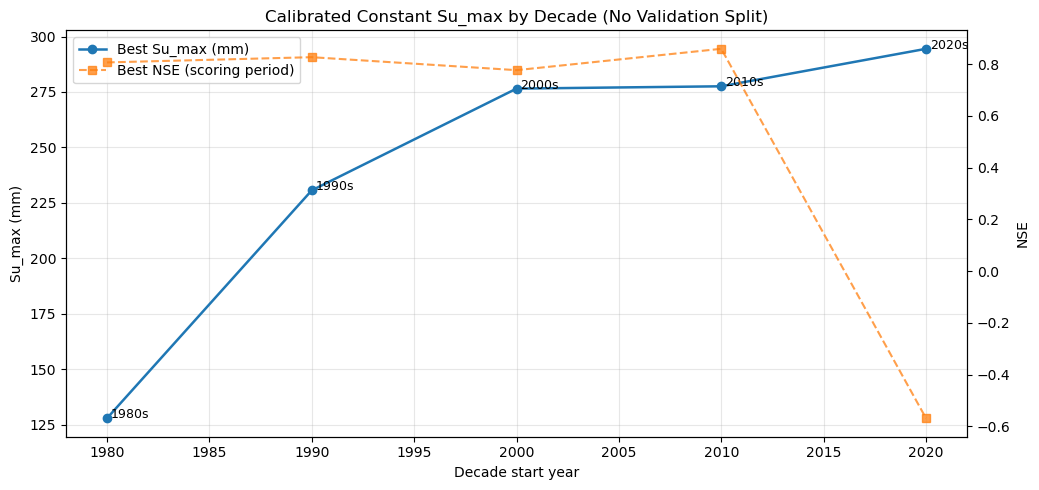

,decade,score_start,score_end,sim_start,spinup_days,n_score_days,valid_runs,best_nse,best_lognse,best_rel_bias,best_Imax,best_Ce,best_Sumax0,best_beta,best_Pmax,best_Tlag,best_Kf,best_Ks,best_Su_max_mm
0,1980s,1980-01-01,1989-12-31,1980-01-01,0,3653,100,0.806175,0.434162,-0.139148,7.900215,0.291725,127.917762,1.624425,0.176482,2.983940,0.233800,0.001738,127.917762
1,1990s,1990-01-01,1999-12-31,1989-01-01,365,3652,100,0.826384,0.190444,-0.094842,7.577215,0.279747,230.652194,1.586803,0.106749,2.271068,0.346716,0.017160,230.652194
2,2000s,2000-01-01,2009-12-31,1999-01-01,365,3653,100,0.776288,0.766278,-0.057503,2.174787,0.455395,276.527725,2.698011,0.297455,6.728140,0.446238,0.006493,276.527725
3,2010s,2010-01-01,2019-12-31,2009-01-01,365,3652,100,0.858771,0.438366,-0.117642,4.392283,0.415106,277.570193,2.384312,0.151577,3.834471,0.261810,0.000302,277.570193
4,2020s,2020-01-01,2025-12-31,2019-01-01,365,2192,100,-0.568393,0.059705,-0.241394,3.081166,0.391753,294.471569,0.824555,0.264002,1.872540,0.020756,0.005837,294.471569


In [8]:
# Plot calibrated Su_max by decade
plot_df = decadal_sumax_df.copy()
plot_df['decade_start_year'] = plot_df['decade'].str.replace('s', '', regex=False).astype(int)

fig, ax1 = plt.subplots(figsize=(10.5, 5))
ax1.plot(
    plot_df['decade_start_year'],
    plot_df['best_Su_max_mm'],
    marker='o',
    linewidth=1.8,
    label='Best Su_max (mm)'
)
ax1.set_xlabel('Decade start year')
ax1.set_ylabel('Su_max (mm)')
ax1.set_title('Calibrated Constant Su_max by Decade (No Validation Split)')
ax1.grid(alpha=0.3)

for _, r in plot_df.iterrows():
    ax1.text(r['decade_start_year'] + 0.2, r['best_Su_max_mm'], r['decade'], fontsize=9)

ax2 = ax1.twinx()
ax2.plot(
    plot_df['decade_start_year'],
    plot_df['best_nse'],
    marker='s',
    linestyle='--',
    alpha=0.75,
    color='tab:orange',
    label='Best NSE (scoring period)'
)
ax2.set_ylabel('NSE')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

decadal_sumax_df

In [9]:
# Table of all best-fit HBV parameters for each decade
required_cols = [
    'decade', 'best_Imax', 'best_Ce', 'best_Sumax0', 'best_beta',
    'best_Pmax', 'best_Tlag', 'best_Kf', 'best_Ks'
]

if 'decadal_sumax_df' not in globals():
    raise RuntimeError('Run the decadal calibration cell first to create decadal_sumax_df.')

missing = [c for c in required_cols if c not in decadal_sumax_df.columns]
if missing:
    raise RuntimeError(
        'Missing parameter columns in decadal_sumax_df: ' + str(missing) +
        '. Re-run the decadal calibration cell to store all best parameters.'
    )

best_params_by_decade = decadal_sumax_df[required_cols].copy()
best_params_by_decade = best_params_by_decade.sort_values('decade').reset_index(drop=True)

for c in best_params_by_decade.columns:
    if c != 'decade':
        best_params_by_decade[c] = best_params_by_decade[c].round(4)

print('Best parameters for each decade:')
best_params_by_decade

Best parameters for each decade:


,decade,best_Imax,best_Ce,best_Sumax0,best_beta,best_Pmax,best_Tlag,best_Kf,best_Ks
0,1980s,7.9002,0.2917,127.9178,1.6244,0.1765,2.9839,0.2338,0.0017
1,1990s,7.5772,0.2797,230.6522,1.5868,0.1067,2.2711,0.3467,0.0172
2,2000s,2.1748,0.4554,276.5277,2.6980,0.2975,6.7281,0.4462,0.0065
3,2010s,4.3923,0.4151,277.5702,2.3843,0.1516,3.8345,0.2618,0.0003
4,2020s,3.0812,0.3918,294.4716,0.8246,0.2640,1.8725,0.0208,0.0058
